<a href="https://colab.research.google.com/github/Doommen3/data_science_portfolio/blob/main/Presentation_edit3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group 2 - MPSDDS

In [73]:
import pandas as pd
import numpy as np

In [74]:
from IPython.display import IFrame


published_url = "https://docs.google.com/presentation/d/e/2PACX-1vRG1M9kzx3F4IfInhWV6daXwZUuJG8RYCcDKepXdopE48XqOJhzO5dYV_KVXBs-tKBhsL_0Xx-tgeKf/pubembed?start=false&loop=false&delayms=3000"

IFrame(src=published_url, width=960, height=569)


/content/anes_timeseries_2024_csv_20250430.zip



---



In [75]:
# I need more information to proceed. Please provide the following:
# 1. The path to your dataset.
# 2. The column name corresponding to 'v240002a' (interview mode).
# 3. The column name corresponding to 'v240002c' (pre-interview completion).
# 4. The column name indicating completion of both pre- and post-interviews.

# Once you provide this information, I can write the code to perform the comparison.

Rows × Cols: (5521, 6)


/tmp/ipython-input-1022560594.py:7: DtypeWarning: Columns (2,3,8,10,11,16,18,19,20,22,23,24,26,27,28,30,31,32,34,35,1284,1285) have mixed types. Specify dtype option on import or set low_memory=False.
  anes = pd.read_csv("/content/anes_timeseries_2024_csv_20250430.csv")


,attrit_flag,mode,sex,interest,prim_vote,registered
0,Stayed,Web,Male,Very,1.0,Yes
1,Stayed,Web,Female,Not much,1.0,Yes
2,Stayed,Web,Female,Very,1.0,Yes
3,Stayed,Web,Male,Some,0.0,Yes
4,Stayed,Web,Male,Some,0.0,Yes



Missingness (%):


,0
registered,5.0
prim_vote,4.8
interest,4.5
sex,0.8
mode,0.0
attrit_flag,0.0


...

,Attrited,Stayed,All
Very,201,2427,2628
Some,224,1726,1950
Not much,87,610,697
All,512,4763,5275



PRIM_VOTE × ATTRITION


,Attrited,Stayed,All
0.0,328,2628,2956
1.0,181,2118,2299
All,509,4746,5255



REGISTERED × ATTRITION


,Attrited,Stayed,All
No,62,327,389
Yes,445,4410,4855
All,507,4737,5244


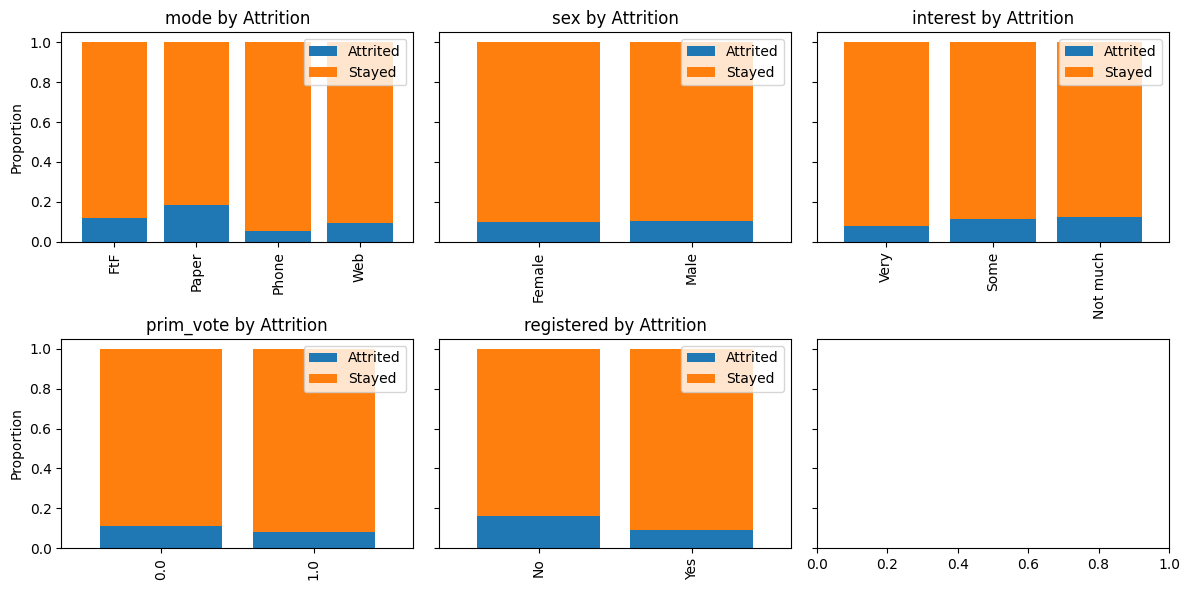

In [76]:
# ---------------------------------------------------------------------
# 0. Set-up  ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

anes = pd.read_csv("/content/anes_timeseries_2024_csv_20250430.csv")

anes["post_participated"] = (anes["V240002c"] == 2).astype(int)  # 2 = did post

mode_map = {1: "f2f", 2: "internet", 3: "paper", 4: "phone"}     # pre-wave modes
anes["mode"] = anes["V240002a"].replace(mode_map)                #
anes.loc[anes["V240002a"] < 0, "mode"] = np.nan                  # missing → NaN

anes["male"] = np.where(anes["V241550"] == 1, 1,
                np.where(anes["V241550"] == 2, 0, np.nan))       #

anes["interest"] = anes["V241005"].where(anes["V241005"] > 0)    # 1 Very … 3 Not much

anes["primary_vote"] = np.where(anes["V241031"] == 3, 0,
                       np.where(anes["V241031"] > 0, 1, np.nan)) # 1/2 = voted primary

anes["registered"] = np.where(anes["V241012"] == 1, 1,
                     np.where(anes["V241012"] == 2, 0, np.nan))

cols = ["post_participated", "mode", "male", "interest",
        "primary_vote", "registered"]

# ---------------------------------------------------------------------
# 1. Keep variables of interest  --------------------------------------
keep_cols = {
    "post_participated" : "attrit_flag",   # 1 = stayed, 0 = attrited
    "V240002a"           : "mode",          # interview mode (1–5)
    "V241550"           : "sex",           # 1 = male, 2 = female
    "V241005"           : "interest",      # 1 = very, 2 = some, 3 = not much
    "primary_vote"      : "prim_vote",     # 1/0/NaN (you built this)
    "V241012"           : "registered"     # 1 = yes, 2 = no
}
anes = anes[list(keep_cols)].rename(columns=keep_cols)

# recode categorical labels
anes["mode"] = anes["mode"].map({
    1: "FtF", 2: "Web", 3: "Paper", 4: "Phone"
})
anes["sex"] = anes["sex"].map({1: "Male", 2: "Female"})
anes["interest"] = pd.Categorical(
    anes["interest"].map({1: "Very", 2: "Some", 3: "Not much"}),
    categories=["Very", "Some", "Not much"],
    ordered=True
)
anes["registered"] = anes["registered"].map({1: "Yes", 2: "No"})
anes["attrit_flag"] = anes["attrit_flag"].map({1: "Stayed", 0: "Attrited"})

# ---------------------------------------------------------------------
# 2. High-level snapshot  ---------------------------------------------
print("Rows × Cols:", anes.shape)
display(anes.head())

print("\nMissingness (%):")
display( (anes.isna().mean()*100).round(1).sort_values(ascending=False) )

# ---------------------------------------------------------------------
# 3. Un-weighted frequency tables  ------------------------------------
for col in ["mode","sex","interest","prim_vote","registered"]:
    print(f"\n{col.upper()} – value counts")
    display( anes[col].value_counts(dropna=False).to_frame("n")
               .assign(pct=lambda d: (d["n"]/d["n"].sum()*100).round(1)) )

# ---------------------------------------------------------------------
# 4. Attrition cross-tabs  --------------------------------------------
for col in ["mode","sex","interest","prim_vote","registered"]:
    ct = (pd.crosstab(anes[col], anes["attrit_flag"], margins=True)
            .rename_axis(index=None, columns=None))
    print(f"\n{col.upper()} × ATTRITION")
    display(ct)

# ---------------------------------------------------------------------
# 5. Quick visuals (bar charts)  --------------------------------------
def stacked_bar(var, ax):
    ctab = pd.crosstab(anes[var], anes["attrit_flag"], normalize="index")
    ctab.plot(kind="bar", stacked=True, ax=ax, width=0.8)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_title(f"{var} by Attrition")
    ax.legend(title="", loc="upper right")

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, var in zip(axes.flat,
                   ["mode","sex","interest","prim_vote","registered"]):
    stacked_bar(var, ax)
fig.tight_layout()
plt.show()


**Test of independence between \<VAR\> and post-wave completion**

Let  

$$
Y =
\begin{cases}
 1 & \text{respondent completed the post-election interview}\\[4pt]
 0 & \text{respondent attrited after the pre-election interview}
\end{cases},
\qquad
X \in \{1,\dots,k\}\!,
$$

where $(X) is a (k)$-category predictor  
$(\texttt{mode}:k=4), (\texttt{male}:k=2), (\texttt{interest}:k=3),  
(\texttt{primary\_vote}:k=2), (\texttt{registered}:k=2)$).

Null and alternative hypotheses:

$$
H_0:\; X \text{ and } Y \text{ are independent}
\quad\Longleftrightarrow\quad
\Pr(Y=j\mid X=i)=\Pr(Y=j)
\;(i=1,\dots,k;\;j=0,1),
$$

with Pearson’s statistic  

$$
\chi^2=\sum_{i=1}^{k}\sum_{j=0}^{1}
\frac{(O_{ij}-E_{ij})^{2}}{E_{ij}},
\qquad
E_{ij}=\frac{n_{i\cdot}\,n_{\cdot j}}{n},
\qquad
\chi^2\sim\chi^{2}_{k-1}\;\text{ under }H_0.
$$

Reject $H_0$ when ($chi^2>\chi^{2}_{1-\alpha,\;k-1}$).

The p-value is  

$$
p=1-F_{\chi^{2}_{k-1}}\!\bigl(\chi^2_{\text{obs}}\bigr).
$$


In [79]:
import pandas as pd
import numpy as np
from   scipy.stats import chi2_contingency
import statsmodels.api as sm


anes = pd.read_csv("/content/anes_timeseries_2024_csv_20250430.csv",
                   low_memory=False)

anes["post_participated"] = (anes["V240002c"] == 2).astype(int)  # 2 = completed post

# interview mode (pre-wave)  1 FtF | 2 Internet | 3 Paper | 4 Phone
anes["mode"] = anes["V240002a"].replace({1:"f2f", 2:"internet",
                                         3:"paper", 4:"phone"})
anes.loc[anes["V240002a"] < 0, "mode"] = np.nan  # drop ANES negative missings

anes["male"] = anes["V241550"].replace({1:1, 2:0}).where(anes["V241550"] > 0)

anes["interest"]      = anes["V241005"].where(anes["V241005"] > 0)  # 1,2,3
anes["primary_vote"]  = np.where(anes["V241031"].isin([1,2]), 1,
                         np.where(anes["V241031"] == 3, 0, np.nan))
anes["registered"]    = anes["V241012"].replace({1:1, 2:0}).where(anes["V241012"] > 0)


def chi2_print(df, cat, flag, alpha=0.05):
    """
    Pearson χ² test of independence between `cat` and `flag`.
    Prints the contingency table, test statistic, p-value,
    and the α-level decision.
    """
    tmp   = df[[cat, flag]].dropna()
    table = pd.crosstab(tmp[cat], tmp[flag])

    chi2, p, dof, _ = chi2_contingency(table, correction=False)

    print(f"\n===== {cat} vs {flag} =====")
    print(table)
    print(f"Pearson χ² = {chi2:.2f}  (dof = {dof}),  p = {p:.4f}")

    if p < alpha:
        print(f"Decision @ α = {alpha}:  **Reject H0**")
    else:
        print(f"Decision @ α = {alpha}:  Fail to reject H0")


chi_vars = ["mode", "male", "interest", "primary_vote", "registered"]
for var in chi_vars:
    chi2_print(anes, var, "post_participated")




===== mode vs post_participated =====
post_participated    0     1
mode                        
f2f                113   853
internet           395  3839
paper               45   200
phone                4    72
Pearson χ² = 25.91  (dof = 3),  p = 0.0000
Decision @ α = 0.05:  **Reject H0**

===== male vs post_participated =====
post_participated    0     1
male                        
0.0                285  2646
1.0                259  2285
Pearson χ² = 0.32  (dof = 1),  p = 0.5728
Decision @ α = 0.05:  Fail to reject H0

===== interest vs post_participated =====
post_participated    0     1
interest                    
1.0                201  2427
2.0                224  1726
3.0                 87   610
Pearson χ² = 25.88  (dof = 2),  p = 0.0000
Decision @ α = 0.05:  **Reject H0**

===== primary_vote vs post_participated =====
post_participated    0     1
primary_vote                
0.0                328  2628
1.0                181  2118
Pearson χ² = 15.36  (dof = 1),  p = 0.000


$Y_i \
;\sim\; \text{Bernoulli}(\pi_i),
  \qquad
  \text{logit}(\pi_i)
  \;=\;
  \log\Bigl(\tfrac{\pi_i}{1-\pi_i}\Bigr)
  \;=\;
  \beta_0
  \;+\;
  \beta_1\,\text{Male}_i
  \;+\;
  \beta_2\,\text{PrimaryVote}_i
  \;+\;
  \beta_3\,\text{Registered}_i
  \;+\;
  \beta_4\,D^{\text{Internet}}_i
  \;+\;
  \beta_5\,D^{\text{Paper}}_i
  \;+\;
  \beta_6\,D^{\text{Phone}}_i
  \;+\;
  \beta_7\,D^{\text{Interest}= \text{Some}}_i
  \;+\;
  \beta_8\,D^{\text{Interest}= \text{Not much}}_i .$
  \

\begin{aligned}
  &\text{where} \\
  &\quad Y_i
     = \begin{cases}
         1 & \text{respondent } i \text{ completed the {post-election} wave} \\
         0 & \text{respondent } i \text{ attrited after the pre-election wave}
       \end{cases}\\[6pt]
  &\quad \text{Male}_i
     = \mathbb{1}(\text{sex observed as male}) \\[2pt]
  &\quad \text{PrimaryVote}_i
     = \mathbb{1}(\text{voted in any 2024 presidential primary/caucus}) \\[2pt]
  &\quad \text{Registered}_i
     = \mathbb{1}(\text{currently registered to vote}) \\[6pt]
  &\quad D^{\text{Internet}}_i,\,D^{\text{Paper}}_i,\,D^{\text{Phone}}_i
     = \text{interview-mode dummies (reference = Face-to-face)} \\[6pt]
  &\quad D^{\text{Interest}= \text{Some}}_i,\,D^{\text{Interest}= \text{Not much}}_i
     = \text{campaign-interest dummies (reference = ``Very interested'').}
\end{aligned}



In [78]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

anes = pd.read_csv("/content/anes_timeseries_2024_csv_20250430.csv",
                   low_memory=False)                       # fallback

anes["post_participated"] = (anes["V240002c"] == 2).astype(int)  # 2 = did post

mode_map = {1: "f2f", 2: "internet", 3: "paper", 4: "phone"}     # pre-wave modes
anes["mode"] = anes["V240002a"].replace(mode_map)                #
anes.loc[anes["V240002a"] < 0, "mode"] = np.nan                  # missing → NaN

anes["male"] = np.where(anes["V241550"] == 1, 1,
                np.where(anes["V241550"] == 2, 0, np.nan))       #

anes["interest"] = anes["V241005"].where(anes["V241005"] > 0)    # 1 Very … 3 Not much

anes["primary_vote"] = np.where(anes["V241031"] == 3, 0,
                       np.where(anes["V241031"] > 0, 1, np.nan)) # 1/2 = voted primary

anes["registered"] = np.where(anes["V241012"] == 1, 1,
                     np.where(anes["V241012"] == 2, 0, np.nan))

cols = ["post_participated", "mode", "male", "interest",
        "primary_vote", "registered"]
df = anes[cols].dropna()

df = pd.get_dummies(df,
                    columns=["mode", "interest"],   # f2f & Very are references
                    drop_first=True,
                    dtype=float)                    # forces 0/1 float

df = df.loc[:, df.std() > 0]

y = df["post_participated"]
X = sm.add_constant(df.drop(columns="post_participated"))


uw_res = sm.Logit(y, X).fit()
print(uw_res.summary())
print("Odds ratios:\n", np.exp(uw_res.params))


Optimization terminated successfully.
         Current function value: 0.309858
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      post_participated   No. Observations:                 5184
Model:                          Logit   Df Residuals:                     5176
Method:                           MLE   Df Model:                            7
Date:                Thu, 07 Aug 2025   Pseudo R-squ.:                 0.01376
Time:                        19:27:16   Log-Likelihood:                -1606.3
converged:                       True   LL-Null:                       -1628.7
Covariance Type:            nonrobust   LLR p-value:                 1.478e-07
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.9021      0.195      9.742      0.000       1.519       2.285
male             -0.